# Homework 3 Logistic Regression Analysis

So here, we look at whether the two accident types are really different, how well logistic regression works on the data, which features matter most, and what changes when 'FIRM' is removed.


# Common functions for all files

I made this common cell to hold the parts of the code that every question needed.

Instead of rewriting the same setup four different times, I decided to put the shared steps in one file. That includes loading the data, building the logistic regression model, testing it, and saving the graphs and summary files.

So the point of the cell below is just to keep the question files shorter and just overall easier to read. This is so that question file can focus on its own part, while this handles the repeated setup in the background.



In [5]:
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
PERMUTATION_REPEATS = 10
ROOT = Path.cwd()
DATA_PATH = ROOT / "FRAFirm.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


@dataclass
class EvaluationSummary:
    task_name: str
    labels: list[str]
    class_counts: dict[str, int]
    majority_baseline_accuracy: float
    cv_accuracy: float
    cv_balanced_accuracy: float
    cv_macro_f1: float
    holdout_accuracy: float
    holdout_balanced_accuracy: float
    holdout_macro_f1: float
    confusion_matrix: list[list[int]]
    classification_report: dict[str, Any]
    top_features: list[dict[str, float]]


def load_dataset() -> pd.DataFrame:
    return pd.read_csv(DATA_PATH)


def build_pipeline(frame: pd.DataFrame, include_firm: bool) -> Pipeline:
    feature_frame = frame.drop(columns=["class"])
    numeric_columns = [
        column
        for column in feature_frame.columns
        if column != "FIRM" and feature_frame[column].nunique() > 1
    ]
    categorical_columns = ["FIRM"] if include_firm and "FIRM" in feature_frame.columns else []

    transformers = [
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_columns,
        )
    ]

    if categorical_columns:
        transformers.append(
            (
                "firm",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical_columns,
            )
        )

    return Pipeline([
        ("preprocessor", ColumnTransformer(transformers, remainder="drop")),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
            ),
        ),
    ])


def save_confusion_matrix(task_name: str, matrix: np.ndarray, labels: list[str]) -> None:
    figure, axis = plt.subplots(figsize=(6, 5))
    display_plot = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    display_plot.plot(ax=axis, cmap="Blues", colorbar=False)
    axis.set_title(f"{task_name.replace('_', ' ').title()} Confusion Matrix")
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / f"{task_name}_confusion_matrix.png", dpi=200)
    plt.close(figure)


def save_importance_chart(task_name: str, importance_frame: pd.DataFrame) -> None:
    top_rows = importance_frame.head(10).iloc[::-1]
    figure, axis = plt.subplots(figsize=(8, 5))
    sns.barplot(data=top_rows, x="mean_importance", y="feature", ax=axis, color="#4C78A8")
    axis.set_title(f"{task_name.replace('_', ' ').title()} Feature Importance")
    axis.set_xlabel("Average importance")
    axis.set_ylabel("Feature")
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / f"{task_name}_feature_importance.png", dpi=200)
    plt.close(figure)


def save_report_csv(task_name: str, report: dict[str, Any]) -> None:
    pd.DataFrame(report).transpose().to_csv(OUTPUT_DIR / f"{task_name}_classification_report.csv")


def evaluate_pipeline(*, frame: pd.DataFrame, target: pd.Series, task_name: str, labels: list[str], include_firm: bool) -> EvaluationSummary:
    feature_frame = frame.drop(columns=["class"])
    pipeline = build_pipeline(frame, include_firm=include_firm)
    splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    cv_scores = cross_validate(
        pipeline,
        feature_frame,
        target,
        cv=splitter,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "macro_f1": "f1_macro",
        },
    )

    train_features, test_features, train_target, test_target = train_test_split(
        feature_frame,
        target,
        test_size=TEST_SIZE,
        stratify=target,
        random_state=RANDOM_STATE,
    )

    pipeline.fit(train_features, train_target)
    predictions = pipeline.predict(test_features)

    matrix = confusion_matrix(test_target, predictions)
    report = classification_report(
        test_target,
        predictions,
        output_dict=True,
        target_names=labels,
        zero_division=0,
    )

    importance = permutation_importance(
        pipeline,
        test_features,
        test_target,
        scoring="balanced_accuracy",
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
    )

    importance_frame = pd.DataFrame(
        {
            "feature": test_features.columns,
            "mean_importance": importance.importances_mean,
            "std_importance": importance.importances_std,
        }
    ).sort_values("mean_importance", ascending=False)

    save_confusion_matrix(task_name, matrix, labels)
    save_importance_chart(task_name, importance_frame)
    save_report_csv(task_name, report)

    class_counts = target.value_counts().sort_index()

    return EvaluationSummary(
        task_name=task_name,
        labels=labels,
        class_counts={str(key): int(value) for key, value in class_counts.items()},
        majority_baseline_accuracy=float(class_counts.max() / class_counts.sum()),
        cv_accuracy=float(np.mean(cv_scores["test_accuracy"])),
        cv_balanced_accuracy=float(np.mean(cv_scores["test_balanced_accuracy"])),
        cv_macro_f1=float(np.mean(cv_scores["test_macro_f1"])),
        holdout_accuracy=float(accuracy_score(test_target, predictions)),
        holdout_balanced_accuracy=float(balanced_accuracy_score(test_target, predictions)),
        holdout_macro_f1=float(f1_score(test_target, predictions, average="macro")),
        confusion_matrix=matrix.tolist(),
        classification_report=report,
        top_features=[
            {
                "feature": row.feature,
                "mean_importance": float(row.mean_importance),
                "std_importance": float(row.std_importance),
            }
            for row in importance_frame.head(10).itertuples(index=False)
        ],
    )


def write_summary(filename: str, summaries: list[EvaluationSummary]) -> None:
    payload = {summary.task_name: asdict(summary) for summary in summaries}
    with (OUTPUT_DIR / filename).open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)


def print_summary(summary: EvaluationSummary) -> None:
    print(summary.task_name)
    print(f"  holdout_accuracy={summary.holdout_accuracy:.4f}")
    print(f"  holdout_balanced_accuracy={summary.holdout_balanced_accuracy:.4f}")
    print(f"  holdout_macro_f1={summary.holdout_macro_f1:.4f}")
    print(f"  top_feature={summary.top_features[0]['feature']}")


# Question 1: Are accident types 1 and 2 distinguishable?

I tested this by keeping only the accident rows and asking the model to tell `ype 1 from Type 2.

The result wasn't very strong. The holdout accuracy was only like 53.3%, and the balanced accuracy was about 50.7%. It's only a little better than guessing. So I can conclude that the model isn't doing a good job separating the two accident types.

So my answer is that the two accident types do not look clearly different in this dataset. Because of this, I think it makes more sense to group them together as just Accident for the other jobs.


type1_vs_type2
  holdout_accuracy=0.5332
  holdout_balanced_accuracy=0.5067
  holdout_macro_f1=0.4900
  top_feature=AFZ


,Pred Type 1,Pred Type 2
Actual Type 1,211,163
Actual Type 2,76,62


,feature,mean_importance,std_importance
0,AFZ,0.022008,0.012061
1,Comp,0.009471,0.005032
2,Start,0.005024,0.003896
3,MFZ,0.004464,0.003312
4,Length,0.003023,0.011246
5,Trans,0.002643,0.011651
6,p1l,0.000314,0.007551
7,MalAdj,0.000000,0.000000
8,Base,-0.001726,0.006423
9,Night,-0.001726,0.006423


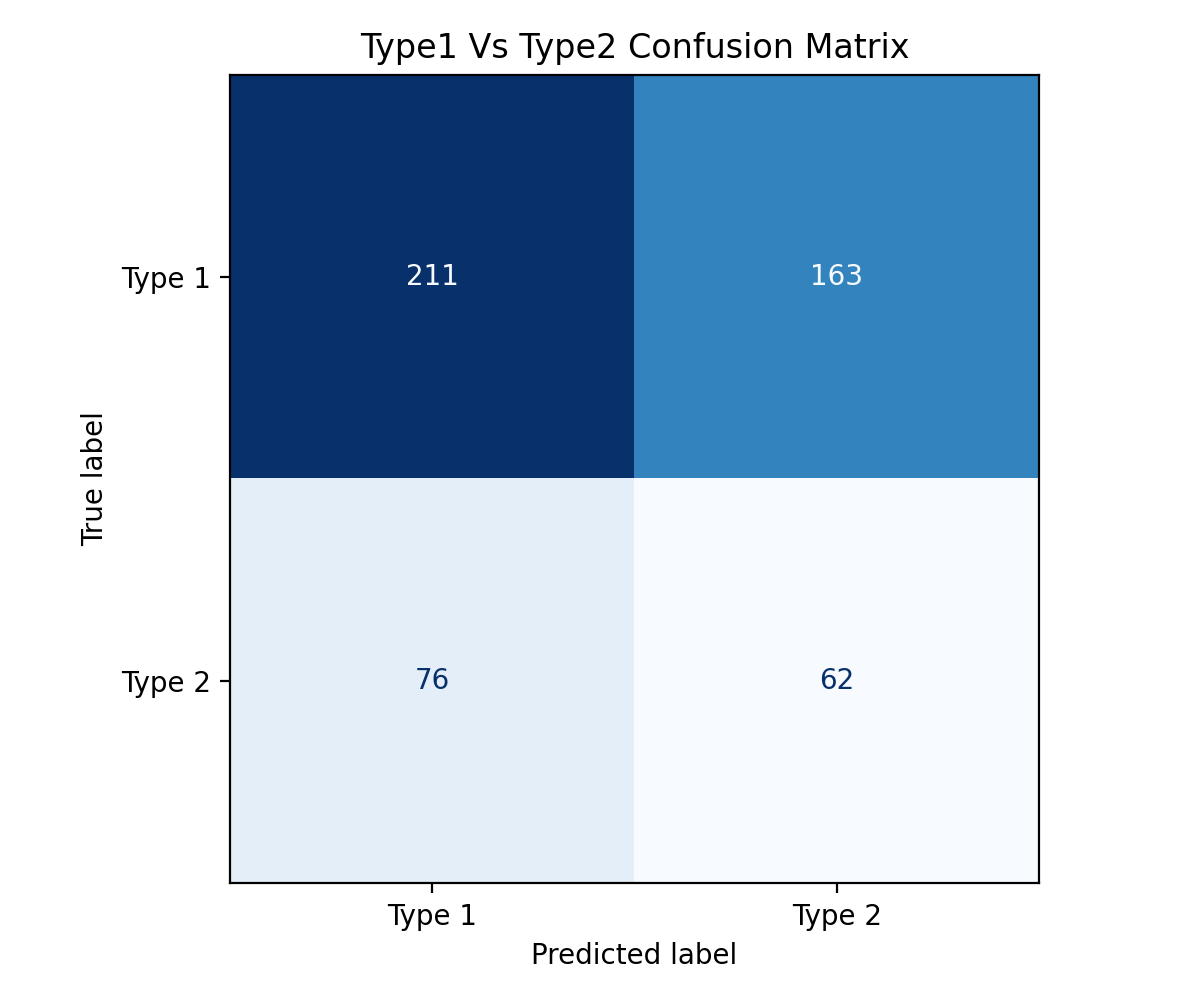

In [6]:
frame = load_dataset()
accident_only = frame.loc[frame["class"] > 0].copy()
target = accident_only["class"].replace({1: 0, 2: 1})

question1_summary = evaluate_pipeline(
    frame=accident_only,
    target=target,
    task_name="type1_vs_type2",
    labels=["Type 1", "Type 2"],
    include_firm=True,
)

write_summary("question1_summary.json", [question1_summary])
print_summary(question1_summary)

display(pd.DataFrame(
    question1_summary.confusion_matrix,
    index=["Actual Type 1", "Actual Type 2"],
    columns=["Pred Type 1", "Pred Type 2"],
))
display(pd.DataFrame(question1_summary.top_features))
display(Image(filename=str(OUTPUT_DIR / "type1_vs_type2_confusion_matrix.png")))


# Question 2: How accurately does the regressor classify the samples?

I looked at this in two different ways.

First, I tried the full 3-class version: No Accident, Type 1, and Type 2. That model had about 73.4% holdout accuracy, but its balanced accuracy was only about 49.7%. So even though the overall accuracy looks okay, it is not handling the accident classes very well.

Then, I combined Type 1 and Type 2 into one 'Accident' class. That worked much better. The holdout accuracy was 79.4%, and the balanced accuracy was about 76.1%.

So overall, the model does a decent job when the problem is just 'No Accident' versus 'Accident', but not a very good job when I force it to split accidents into two separate types. The confusion matrices below say the same thing.


three_class
  holdout_accuracy=0.7335
  holdout_balanced_accuracy=0.4967
  holdout_macro_f1=0.3922
  top_feature=Length
binary_accident
  holdout_accuracy=0.7935
  holdout_balanced_accuracy=0.7606
  holdout_macro_f1=0.5972
  top_feature=Length


,Pred No Accident,Pred Type 1,Pred Type 2
Actual No Accident,5464,747,1029
Actual Type 1,98,191,85
Actual Type 2,42,65,31


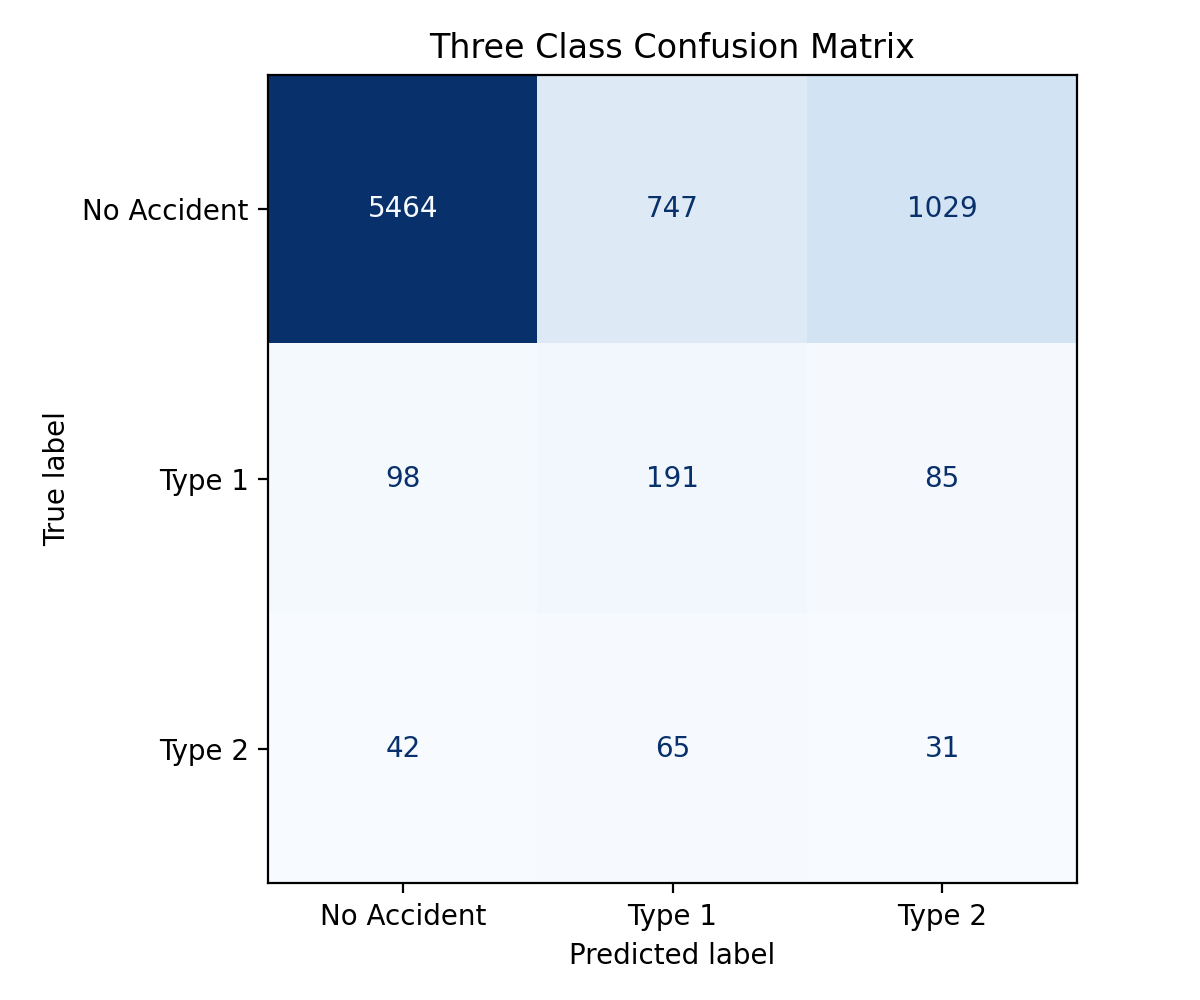

,Pred No Accident,Pred Accident
Actual No Accident,5781,1459
Actual Accident,142,370


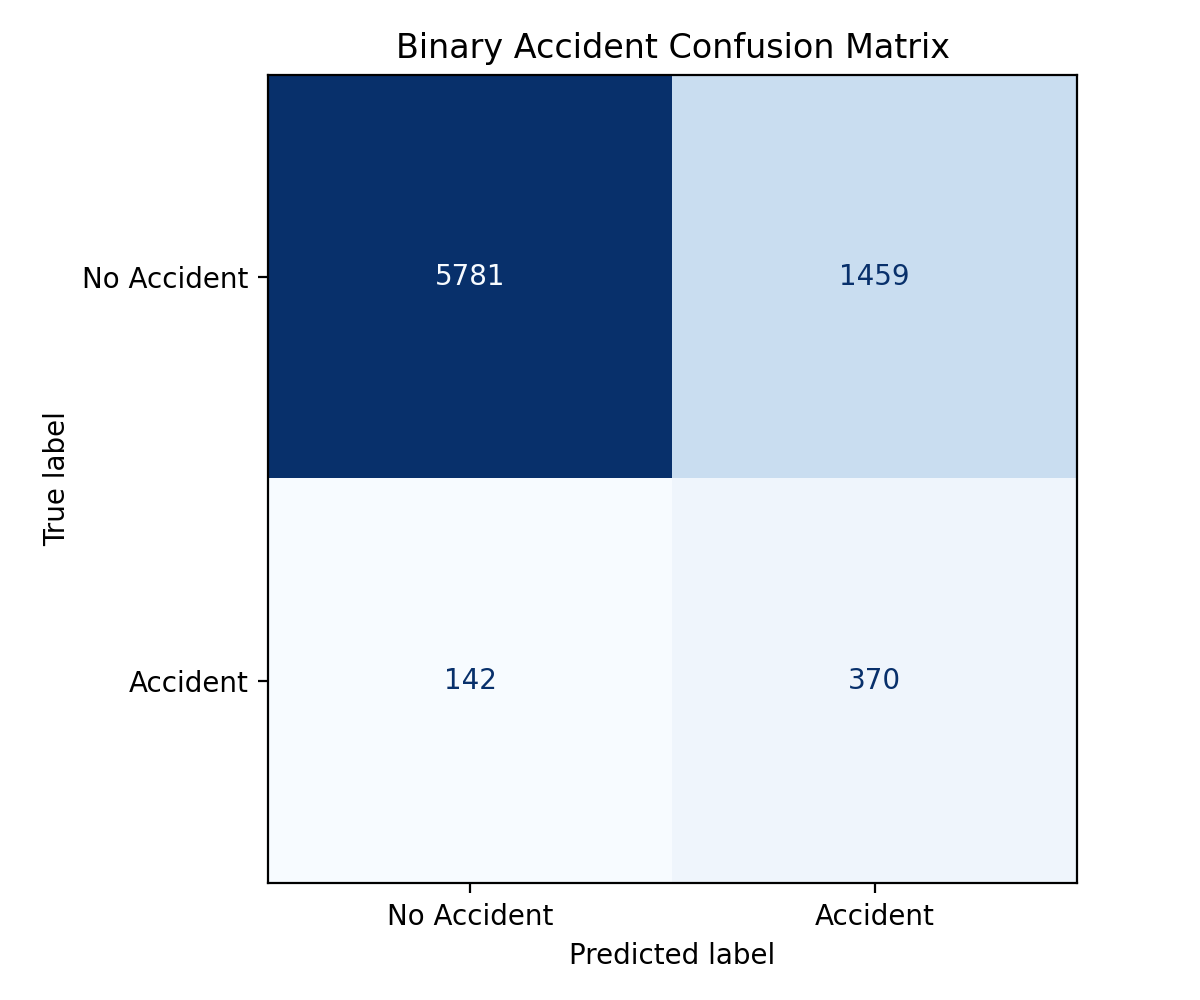

In [7]:
frame = load_dataset()

question2_three_class = evaluate_pipeline(
    frame=frame,
    target=frame["class"],
    task_name="three_class",
    labels=["No Accident", "Type 1", "Type 2"],
    include_firm=True,
)

question2_binary = evaluate_pipeline(
    frame=frame,
    target=(frame["class"] > 0).astype(int),
    task_name="binary_accident",
    labels=["No Accident", "Accident"],
    include_firm=True,
)

write_summary("question2_summary.json", [question2_three_class, question2_binary])
print_summary(question2_three_class)
print_summary(question2_binary)

display(pd.DataFrame(
    question2_three_class.confusion_matrix,
    index=["Actual No Accident", "Actual Type 1", "Actual Type 2"],
    columns=["Pred No Accident", "Pred Type 1", "Pred Type 2"],
))
display(Image(filename=str(OUTPUT_DIR / "three_class_confusion_matrix.png")))

display(pd.DataFrame(
    question2_binary.confusion_matrix,
    index=["Actual No Accident", "Actual Accident"],
    columns=["Pred No Accident", "Pred Accident"],
))
display(Image(filename=str(OUTPUT_DIR / "binary_accident_confusion_matrix.png")))


# Question 3: Which features are significant, and which can be ignored?

For this part, I used the simpler No Accident vs. Accident model since that worked better overall.

The features that stood out the most were Length, AFZ, MFZ, End, and NFZ. So shift length and some of the fatigue-related values seem to matter the most for this prediction.

Some other columns had only a small effect, and 'MalAdj' can basically be ignored because it doesn't really change at all in this dataset. A column that never changes can't help the model at all, or at least in this instance.

So, my main takeaway is that the fatigue-related features do seem useful, while a few other columns don't add much.


binary_accident
  holdout_accuracy=0.7935
  holdout_balanced_accuracy=0.7606
  holdout_macro_f1=0.5972
  top_feature=Length


,feature,mean_importance,std_importance
0,Length,0.082524,0.007707
1,AFZ,0.024017,0.000775
2,MFZ,0.013002,0.000318
3,End,0.009516,0.003761
4,NFZ,0.009048,0.000702
5,LenAdj,0.007386,0.002257
6,StartAdj,0.005027,0.003360
7,p1s,0.004275,0.002752
8,idx,0.004116,0.002530
9,WS,0.002720,0.003382


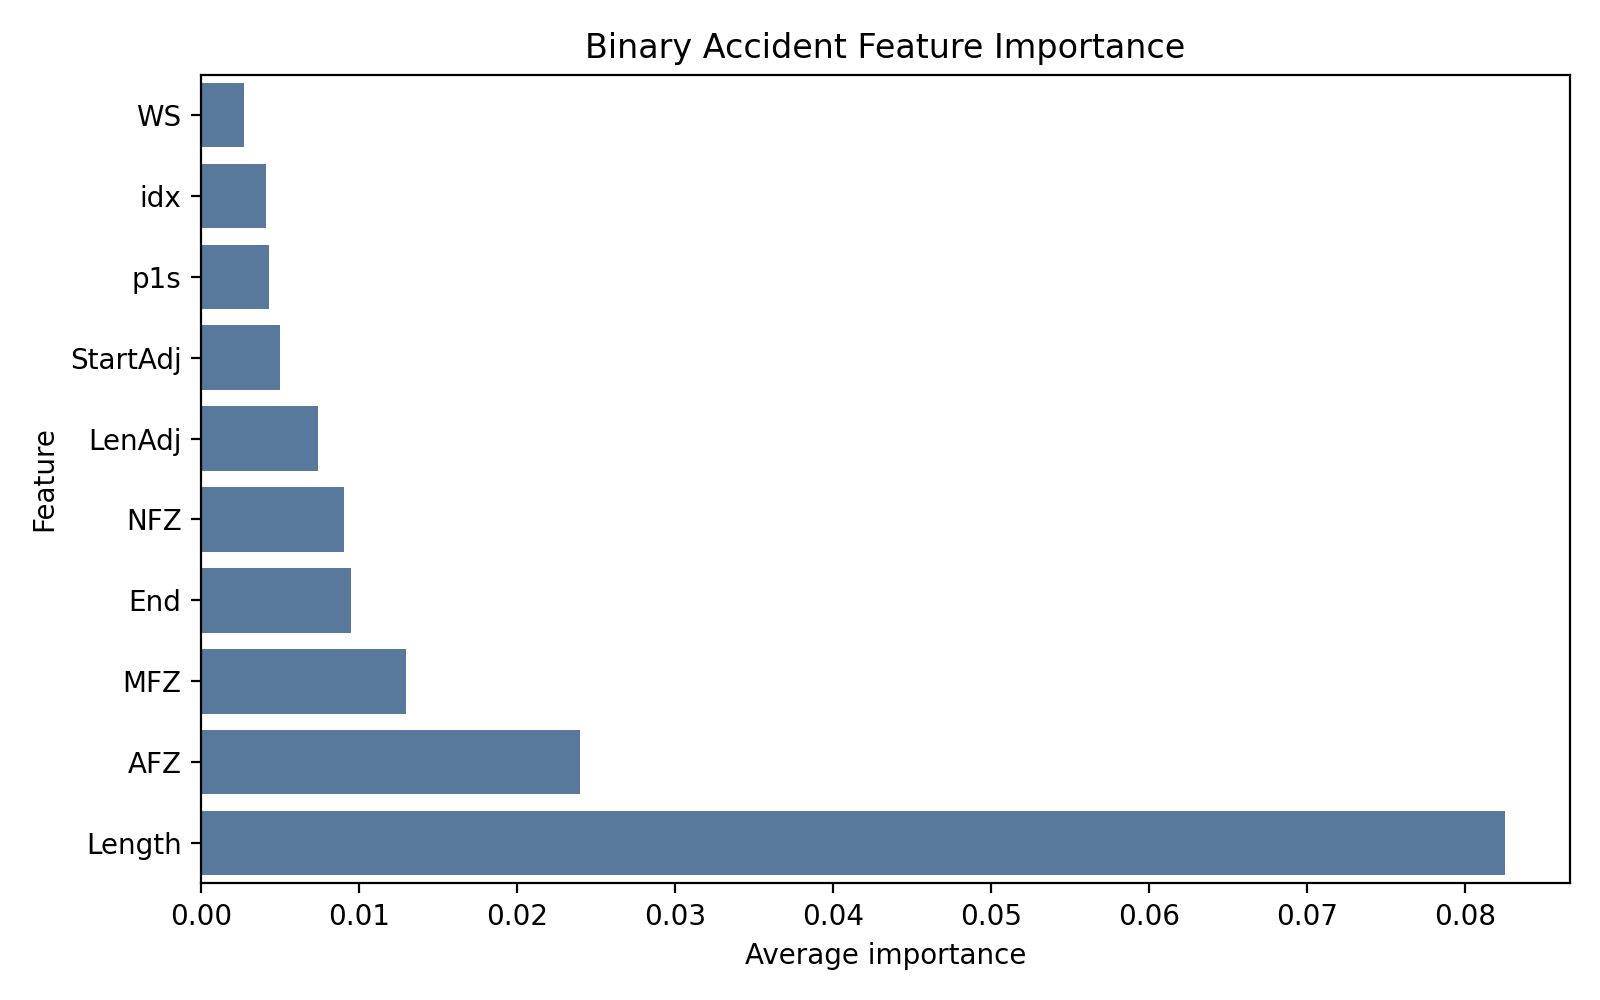

In [4]:
frame = load_dataset()

question3_summary = evaluate_pipeline(
    frame=frame,
    target=(frame["class"] > 0).astype(int),
    task_name="binary_accident",
    labels=["No Accident", "Accident"],
    include_firm=True,
)

write_summary("question3_summary.json", [question3_summary])
print_summary(question3_summary)

display(pd.DataFrame(question3_summary.top_features))
display(Image(filename=str(OUTPUT_DIR / "binary_accident_feature_importance.png")))


# Question 4: What happens if 'FIRM' is removed?

When I removed FIRM and ran the model again, the results barely changed.

With FIRM, the holdout accuracy was about 79.4%. Without FIRM, it was about 79.3%. The balanced accuracy also stayed almost the same.

So, removing FIRM didn't really hurt the model. That tells me the model is getting most of its useful information from the other features, not from the company ID column.


binary_accident
  holdout_accuracy=0.7935
  holdout_balanced_accuracy=0.7606
  holdout_macro_f1=0.5972
  top_feature=Length
binary_without_firm
  holdout_accuracy=0.7928
  holdout_balanced_accuracy=0.7584
  holdout_macro_f1=0.5961
  top_feature=Length


,model,holdout_accuracy,holdout_balanced_accuracy,holdout_macro_f1
0,With FIRM,0.793473,0.760568,0.597238
1,Without FIRM,0.792828,0.758408,0.596122


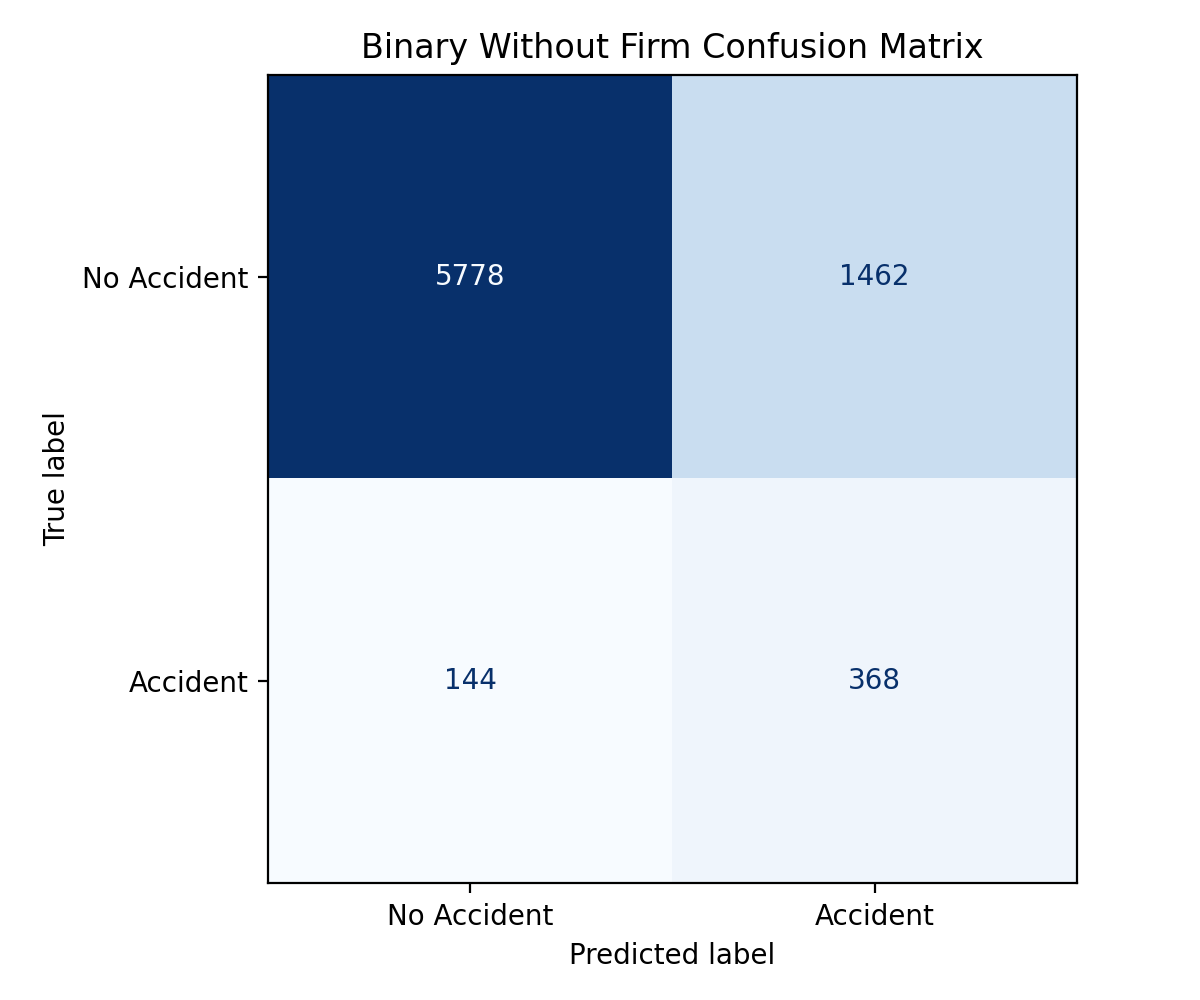

In [8]:
frame = load_dataset()

question4_with_firm = evaluate_pipeline(
    frame=frame,
    target=(frame["class"] > 0).astype(int),
    task_name="binary_accident",
    labels=["No Accident", "Accident"],
    include_firm=True,
)

without_firm_frame = frame.drop(columns=["FIRM"]).copy()
question4_without_firm = evaluate_pipeline(
    frame=without_firm_frame,
    target=(frame["class"] > 0).astype(int),
    task_name="binary_without_firm",
    labels=["No Accident", "Accident"],
    include_firm=False,
)

write_summary("question4_summary.json", [question4_with_firm, question4_without_firm])
print_summary(question4_with_firm)
print_summary(question4_without_firm)

comparison = pd.DataFrame([
    {
        "model": "With FIRM",
        "holdout_accuracy": question4_with_firm.holdout_accuracy,
        "holdout_balanced_accuracy": question4_with_firm.holdout_balanced_accuracy,
        "holdout_macro_f1": question4_with_firm.holdout_macro_f1,
    },
    {
        "model": "Without FIRM",
        "holdout_accuracy": question4_without_firm.holdout_accuracy,
        "holdout_balanced_accuracy": question4_without_firm.holdout_balanced_accuracy,
        "holdout_macro_f1": question4_without_firm.holdout_macro_f1,
    },
])

display(comparison)
display(Image(filename=str(OUTPUT_DIR / "binary_without_firm_confusion_matrix.png")))
